# Week 1 (Module M2) — Data Ingestion, Validation & Preprocessing Pipeline
**Flavor B: Image-Based Defect / Quality Classifier**
Dataset: [Casting Product Image Data for Quality Inspection](https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product) (Kaggle)

This notebook covers the Week 1 deliverables from the project brief:
1. **Ingest** raw image data into a structured manifest
2. **Validate** the data (corrupt files, wrong types, duplicates, class balance)
3. **Preprocess** images (grayscale, resize) and persist a clean copy
4. **Build an augmentation pipeline** (applied on-the-fly at train time in Week 2)
5. **Version the dataset** with DVC

In [1]:
import os
import shutil
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import albumentations as A

pd.set_option("display.max_colwidth", 120)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
  data = fetch_version_info()


## Config

`RAW_DIR` is the untouched Kaggle download — never overwritten by this pipeline.
`PROCESSED_DIR` holds cleaned, resized copies plus the manifest — this is what DVC
will version as "processed data", separately from the raw layer.

In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"

for d in [PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

VALID_EXTENSIONS = {".jpeg", ".jpg", ".png", ".bmp"}
TARGET_SIZE = (224, 224)          # good default if Week 2 uses transfer learning
RANDOM_SEED = 42
CLASS_MAP = {"def_front": 1, "ok_front": 0}   # 1 = defective, 0 = ok


## 1. Ingestion

Walk `RAW_DIR` (expected layout: `<split>/<class>/*.ext`) and build a manifest of
every file found. No validity checks happen here yet — that's a separate step,
deliberately, so the ingestion log and the validation log stay distinguishable.

In [3]:
def build_manifest(raw_dir: Path) -> pd.DataFrame:
    records = []
    for split_dir in sorted(p for p in raw_dir.iterdir() if p.is_dir()):
        split = split_dir.name
        for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
            label_name = class_dir.name
            for filepath in sorted(class_dir.rglob("*")):
                if filepath.is_file():
                    records.append({
                        "filepath": str(filepath),
                        "filename": filepath.name,
                        "split": split,
                        "label_name": label_name,
                        "extension": filepath.suffix.lower(),
                        "file_size_bytes": filepath.stat().st_size,
                    })
    return pd.DataFrame(records)


manifest = build_manifest(RAW_DIR)
print(f"Found {len(manifest)} files under {RAW_DIR}")
manifest.head()


Found 7348 files under ../data/raw


,filepath,filename,split,label_name,extension,file_size_bytes
0,../data/raw/test/def_front/cast_def_0_1059.jpeg,cast_def_0_1059.jpeg,test,def_front,.jpeg,10701
1,../data/raw/test/def_front/cast_def_0_1063.jpeg,cast_def_0_1063.jpeg,test,def_front,.jpeg,9656
2,../data/raw/test/def_front/cast_def_0_108.jpeg,cast_def_0_108.jpeg,test,def_front,.jpeg,11100
3,../data/raw/test/def_front/cast_def_0_1096.jpeg,cast_def_0_1096.jpeg,test,def_front,.jpeg,9797
4,../data/raw/test/def_front/cast_def_0_112.jpeg,cast_def_0_112.jpeg,test,def_front,.jpeg,11642


## 2. Validation

For every file, check that it:
- has an expected extension
- is non-empty
- actually opens as a valid image (catches truncated/corrupt files)
- is single-channel grayscale, as the source dataset promises
- is not an exact duplicate of another file already in the manifest (MD5 hash)

This logic — not just the fact that a manifest exists — is what M2 grading looks at,
so each check is kept explicit and separately reportable rather than collapsed into
one silent pass/fail.

In [4]:
def file_hash(path, chunk_size=8192):
    """MD5 hash of file bytes, used to detect exact duplicates."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def inspect_image(path: str) -> dict:
    """Try to open the file as an image and pull metadata + a validity verdict."""
    result = {"is_readable": False, "width": None, "height": None,
              "mode": None, "file_hash": None, "error": None}
    try:
        with Image.open(path) as img:
            img.verify()                       # cheap corruption check
        with Image.open(path) as img:          # re-open: verify() closes the handle
            result["width"], result["height"] = img.size
            result["mode"] = img.mode
        result["is_readable"] = True
        result["file_hash"] = file_hash(path)
    except (UnidentifiedImageError, OSError, SyntaxError) as e:
        result["error"] = f"{type(e).__name__}: {e}"
    return result


def validate_manifest(manifest: pd.DataFrame, valid_extensions=VALID_EXTENSIONS) -> pd.DataFrame:
    df = manifest.copy()
    df["valid_extension"] = df["extension"].isin(valid_extensions)
    df["non_empty"] = df["file_size_bytes"] > 0

    inspected = df["filepath"].apply(inspect_image).apply(pd.Series)
    df = pd.concat([df, inspected], axis=1)

    df["expected_mode"] = df["mode"] == "L"     # "L" = grayscale
    df["is_duplicate"] = df.duplicated(subset="file_hash", keep="first") & df["file_hash"].notna()

    # A file is "valid" if it's structurally sound and readable.
    # Duplicates are tracked separately and dropped later, rather than
    # counted as invalid, since the file itself isn't corrupt.
    df["is_valid"] = df["valid_extension"] & df["non_empty"] & df["is_readable"]
    return df


validated = validate_manifest(manifest)
validated[["filename", "is_valid", "is_readable", "valid_extension",
           "non_empty", "expected_mode", "is_duplicate", "error"]].head(10)


,filename,is_valid,is_readable,valid_extension,non_empty,expected_mode,is_duplicate,error
0,cast_def_0_1059.jpeg,True,True,True,True,False,False,None
1,cast_def_0_1063.jpeg,True,True,True,True,False,False,None
2,cast_def_0_108.jpeg,True,True,True,True,False,False,None
3,cast_def_0_1096.jpeg,True,True,True,True,False,False,None
4,cast_def_0_112.jpeg,True,True,True,True,False,False,None
5,cast_def_0_1134.jpeg,True,True,True,True,False,False,None
6,cast_def_0_1136.jpeg,True,True,True,True,False,False,None
7,cast_def_0_1137.jpeg,True,True,True,True,False,False,None
8,cast_def_0_1153.jpeg,True,True,True,True,False,False,None
9,cast_def_0_1171.jpeg,True,True,True,True,False,False,None


In [5]:
def summarize_validation(df: pd.DataFrame) -> str:
    lines = []
    lines.append("# Data Validation Report")
    lines.append(f"Generated: {datetime.now().isoformat(timespec='seconds')}")
    lines.append(f"\nTotal files scanned: {len(df)}")
    lines.append(f"Valid, readable images: {int(df['is_valid'].sum())}")
    lines.append(f"Invalid / corrupt / wrong extension: {int((~df['is_valid']).sum())}")
    lines.append(f"Exact duplicates (subset of valid): {int(df['is_duplicate'].sum())}")
    lines.append(f"Unexpected image mode (not grayscale 'L'): "
                  f"{int((~df['expected_mode'] & df['is_valid']).sum())}")

    lines.append("\n## Class / split distribution (valid, de-duplicated images only)")
    clean_subset = df[df["is_valid"] & ~df["is_duplicate"]]
    lines.append(clean_subset.groupby(["split", "label_name"]).size().to_string())

    lines.append("\n## Rejected files")
    rejected = df[~df["is_valid"]][["filepath", "error", "valid_extension", "non_empty"]]
    lines.append(rejected.to_string(index=False) if len(rejected) else "None")

    lines.append("\n## Duplicate files (first occurrence kept, rest dropped)")
    dups = df[df["is_duplicate"]][["filepath"]]
    lines.append(dups.to_string(index=False) if len(dups) else "None")

    return "\n".join(lines)


report_text = summarize_validation(validated)
print(report_text)

report_path = REPORTS_DIR / "validation_report.md"
report_path.write_text(report_text)
print(f"\nSaved to {report_path}")


# Data Validation Report
Generated: 2026-08-06T23:10:34

Total files scanned: 7348
Valid, readable images: 7348
Invalid / corrupt / wrong extension: 0
Exact duplicates (subset of valid): 64
Unexpected image mode (not grayscale 'L'): 7348

## Class / split distribution (valid, de-duplicated images only)
split  label_name
test   def_front      453
       ok_front       262
train  def_front     3758
       ok_front      2811

## Rejected files
None

## Duplicate files (first occurrence kept, rest dropped)
                                      filepath
../data/raw/train/ok_front/cast_ok_0_1001.jpeg
../data/raw/train/ok_front/cast_ok_0_1002.jpeg
../data/raw/train/ok_front/cast_ok_0_1003.jpeg
../data/raw/train/ok_front/cast_ok_0_1019.jpeg
../data/raw/train/ok_front/cast_ok_0_1020.jpeg
../data/raw/train/ok_front/cast_ok_0_1021.jpeg
../data/raw/train/ok_front/cast_ok_0_1022.jpeg
../data/raw/train/ok_front/cast_ok_0_1026.jpeg
../data/raw/train/ok_front/cast_ok_0_1028.jpeg
../data/raw/train/ok_f

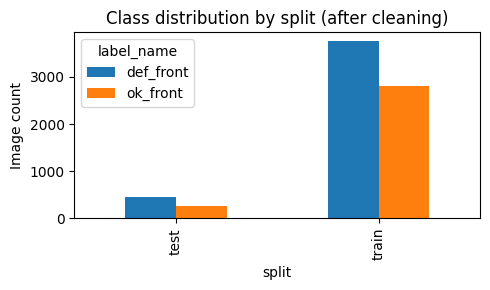

In [6]:
clean = validated[validated["is_valid"] & ~validated["is_duplicate"]].copy()
clean["label"] = clean["label_name"].map(CLASS_MAP)

fig, ax = plt.subplots(figsize=(5, 3))
clean.groupby(["split", "label_name"]).size().unstack().plot(kind="bar", ax=ax)
ax.set_title("Class distribution by split (after cleaning)")
ax.set_ylabel("Image count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()


## 3. Clean manifest

Drop invalid and duplicate rows, then persist the manifest — this is the single
source of truth that Week 2's training notebook should read from, instead of
re-scanning folders.

In [7]:
clean_manifest = clean.drop(columns=["error"]).reset_index(drop=True)
manifest_path = PROCESSED_DIR / "manifest.csv"
clean_manifest.to_csv(manifest_path, index=False)
print(f"Clean manifest saved: {manifest_path} ({len(clean_manifest)} rows)")
clean_manifest.head()


Clean manifest saved: ../data/processed/manifest.csv (7284 rows)


,filepath,filename,split,label_name,extension,file_size_bytes,valid_extension,non_empty,is_readable,width,height,mode,file_hash,expected_mode,is_duplicate,is_valid,label
0,../data/raw/test/def_front/cast_def_0_1059.jpeg,cast_def_0_1059.jpeg,test,def_front,.jpeg,10701,True,True,True,300,300,RGB,4e26d6cf05102659baa357b0405d3b97,False,False,True,1
1,../data/raw/test/def_front/cast_def_0_1063.jpeg,cast_def_0_1063.jpeg,test,def_front,.jpeg,9656,True,True,True,300,300,RGB,110f4382c2e4897c5ef7405e15de1946,False,False,True,1
2,../data/raw/test/def_front/cast_def_0_108.jpeg,cast_def_0_108.jpeg,test,def_front,.jpeg,11100,True,True,True,300,300,RGB,d8700301b355952e83eb3620218b0652,False,False,True,1
3,../data/raw/test/def_front/cast_def_0_1096.jpeg,cast_def_0_1096.jpeg,test,def_front,.jpeg,9797,True,True,True,300,300,RGB,695f2a02f07c7f6831f3818bca2e7909,False,False,True,1
4,../data/raw/test/def_front/cast_def_0_112.jpeg,cast_def_0_112.jpeg,test,def_front,.jpeg,11642,True,True,True,300,300,RGB,b22cbc17c6f36f3cb9192ea01e23c08b,False,False,True,1


## 4. Preprocessing

Enforce single-channel grayscale and a fixed size, then persist the cleaned copy
into `data/processed/`, mirroring the `split/label` folder layout. This is the
artifact DVC will version as the "processed" dataset stage.

In [8]:
def preprocess_and_save(row, target_size=TARGET_SIZE, out_root=PROCESSED_DIR):
    out_dir = out_root / row["split"] / row["label_name"]
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / row["filename"]

    with Image.open(row["filepath"]) as img:
        img = img.convert("L")                        # enforce grayscale
        img = img.resize(target_size, Image.BILINEAR)
        img.save(out_path)

    return str(out_path)


clean_manifest["processed_filepath"] = clean_manifest.apply(preprocess_and_save, axis=1)
clean_manifest.to_csv(manifest_path, index=False)
print(f"Preprocessed {len(clean_manifest)} images into {PROCESSED_DIR}")


Preprocessed 7284 images into ../data/processed


## 5. Augmentation pipeline

Augmentation is applied **on-the-fly at train time** (Week 2's DataLoader/generator
calls `train_transform`), not baked into files on disk — this keeps every epoch
seeing fresh variations instead of a fixed augmented set.

`eval_transform` (no randomness) is what validation/test data and the eventual
API inference path should use, so train/serve preprocessing stays consistent.

In [9]:
train_transform = A.Compose([
    A.Resize(height=TARGET_SIZE[0], width=TARGET_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.2),
])

eval_transform = A.Compose([
    A.Resize(height=TARGET_SIZE[0], width=TARGET_SIZE[1]),
])


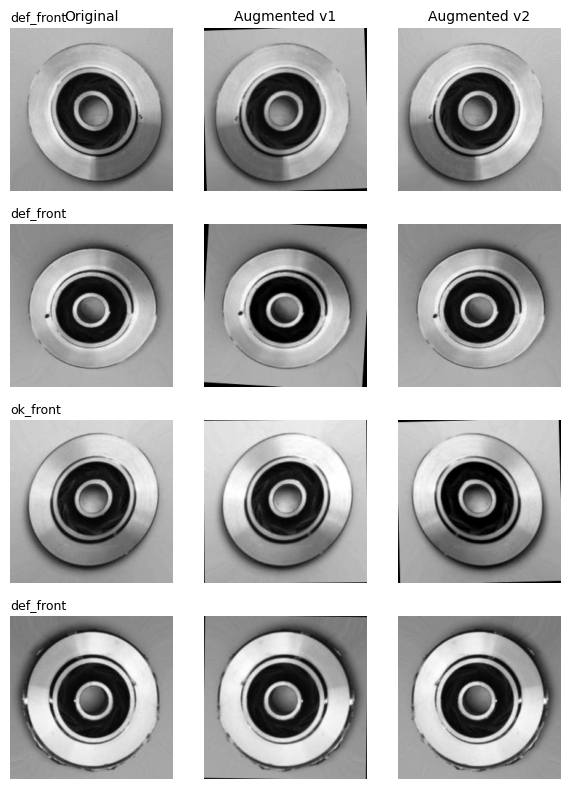

In [10]:
sample_rows = clean_manifest.sample(n=min(4, len(clean_manifest)), random_state=RANDOM_SEED)

fig, axes = plt.subplots(len(sample_rows), 3, figsize=(6, 2 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = axes.reshape(1, -1)

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = np.array(Image.open(row["processed_filepath"]))
    aug1 = train_transform(image=img)["image"]
    aug2 = train_transform(image=img)["image"]

    for j, im in enumerate([img, aug1, aug2]):
        axes[i, j].imshow(im, cmap="gray")
        axes[i, j].axis("off")
    axes[i, 0].set_title(row["label_name"], fontsize=9, loc="left")

axes[0, 0].set_title("Original", fontsize=10)
axes[0, 1].set_title("Augmented v1", fontsize=10)
axes[0, 2].set_title("Augmented v2", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentation_samples.png", dpi=150)
plt.show()
